# Section 1: Sentiment Analysis of the products(ABSA)

In [ ]:
!pip install spacy scikit-learn langgraph langchain

import pandas as pd
import numpy as np
import re
import json
import random
import nltk
import spacy
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, classification_report, matthews_corrcoef

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV

from langgraph.graph import StateGraph
from typing import TypedDict

nltk.download('stopwords')
nltk.download('wordnet')

!python -m spacy download en_core_web_sm

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 55.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('flipkart_product.csv', encoding='ISO-8859-1')

df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')
df = df.dropna(subset=['Rate'])

df['sentiment'] = df['Rate'].apply(lambda x: 1 if x >= 3 else 0)
df['text'] = df['Review'].astype(str) + " " + df['Summary'].astype(str)

df = df[['text', 'sentiment']].dropna()

df_pos = df[df['sentiment'] == 1].sample(25, random_state=42)
df_neg = df[df['sentiment'] == 0].sample(25, random_state=42)

df = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

Saving flipkart_product.csv to flipkart_product (1).csv


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_basic(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess_basic)

In [ ]:
vectorizer_sent = TfidfVectorizer()
X = vectorizer_sent.fit_transform(df['clean_text'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sentiment_model = MultinomialNB()
sentiment_model.fit(X_train, y_train)

y_pred = sentiment_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

def safe_div(a, b):
    return a / b if b != 0 else 0

accuracy = safe_div((TP + TN), (TP + TN + FP + FN))
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

specificity = safe_div(TN, (TN + FP))
fpr = safe_div(FP, (FP + TN))
fnr = safe_div(FN, (FN + TP))
npv = safe_div(TN, (TN + FN))
fdr = safe_div(FP, (TP + FP))

den = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
mcc = (TP*TN - FP*FN) / den if den != 0 else 0

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1 Score:", f1)
print("FPR:", fpr)
print("FNR:", fnr)
print("NPV:", npv)
print("FDR:", fdr)
print("MCC:", mcc)

Confusion Matrix:
 [[5 1]
 [0 4]]
Accuracy: 0.9
Precision: 0.8
Recall: 1.0
Specificity: 0.8333333333333334
F1 Score: 0.8888888888888888
FPR: 0.16666666666666666
FNR: 0.0
NPV: 1.0
FDR: 0.2
MCC: 0.816496580927726


In [ ]:
splits = [0.5, 0.6, 0.7, 0.8, 0.9]

precision_list = []
fpr_list = []
fnr_list = []
npv_list = []
fdr_list = []
mcc_list = []
valid_splits = []

for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=(1-split), random_state=42)

    if len(set(y_test)) < 2:
        continue

    model = MultinomialNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

    precision = precision_score(y_test, y_pred)
    fpr = safe_div(FP, (FP + TN))
    fnr = safe_div(FN, (FN + TP))
    npv = safe_div(TN, (TN + FN))
    fdr = safe_div(FP, (TP + FP))

    den = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    mcc = (TP*TN - FP*FN) / den if den != 0 else 0

    precision_list.append(precision)
    fpr_list.append(fpr)
    fnr_list.append(fnr)
    npv_list.append(npv)
    fdr_list.append(fdr)
    mcc_list.append(mcc)
    valid_splits.append(split)

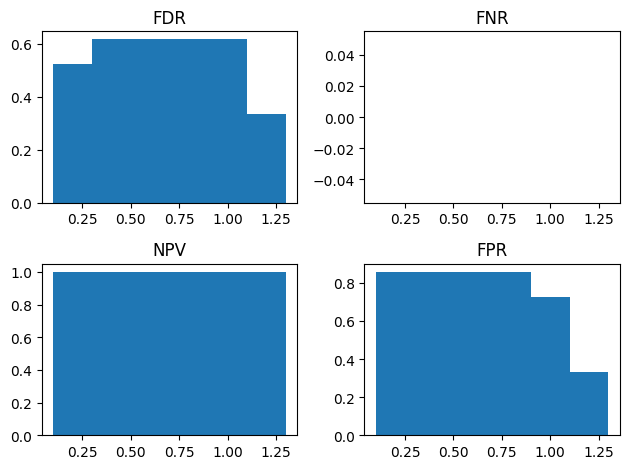

In [ ]:
fig, axs = plt.subplots(2, 2)

axs[0, 0].bar(splits, fdr_list)
axs[0, 0].set_title("FDR")


axs[0, 1].bar(splits, fnr_list)
axs[0, 1].set_title("FNR")

axs[1, 0].bar(splits, npv_list)
axs[1, 0].set_title("NPV")



axs[1, 1].bar(splits, fpr_list)

axs[1, 1].set_title("FPR")

plt.tight_layout()
plt.show()

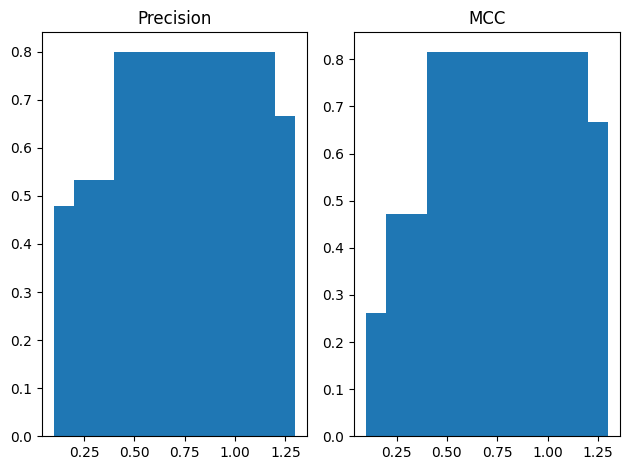

In [ ]:
fig, axs = plt.subplots(1, 2)

axs[0].bar(splits, precision_list)
axs[0].set_title("Precision")



axs[1].bar(splits, mcc_list)
axs[1].set_title("MCC")

plt.tight_layout()
plt.show()

In [ ]:
positive_words = ['good','great','excellent','amazing','nice','super', 'wonderful','awesome','best','perfect','smooth','easy']
negative_words = ['bad','poor','worst','terrible','slow','fade','waste','problem','issue','not','dont','didnt','drain','drains','weak','cheap','faulty','broken']

def extract_aspects(text):
    words = text.split()
    return [w for w in words if w not in positive_words and w not in negative_words]

def aspect_sentiment(text):
    words = text.split()
    result = {}

    if 'but' in words:
        split_index = words.index('but')
    else:
        split_index = -1

    for i, word in enumerate(words):
        if word in positive_words or word in negative_words:
            continue

        window = words[max(0, i-2): i+3]

        pos_score = sum(1 for w in window if w in positive_words)
        neg_score = sum(1 for w in window if w in negative_words)

        if split_index != -1 and i > split_index:
            pos_score *= 1.2
            neg_score *= 1.2

        if 'not' in window or 'dont' in window or 'didnt' in window:
            result[word] = 'Negative'
        elif pos_score > neg_score:
            result[word] = 'Positive'
        elif neg_score > pos_score:
            result[word] = 'Negative'

    return result

In [ ]:
for i in range(50):
    text = df.iloc[i]['clean_text']
    print("Review:", text)
    print("Aspects:", aspect_sentiment(text))

Review: mind blowing purchase best quality beat price thank flipkart
Aspects: {'blowing': 'Positive', 'purchase': 'Positive', 'quality': 'Positive', 'beat': 'Positive'}
Review: nan size perfect
Aspects: {'nan': 'Positive', 'size': 'Positive'}
Review: poor bad product working properly
Aspects: {'product': 'Negative', 'working': 'Negative'}
Review: terrible product good
Aspects: {}
Review: super smooth delivery installation amazing product produce less noise
Aspects: {'delivery': 'Positive', 'installation': 'Positive', 'product': 'Positive', 'produce': 'Positive'}
Review: nan bad product
Aspects: {'nan': 'Negative', 'product': 'Negative'}
Review: expected better product suction good heavy noise
Aspects: {'product': 'Positive', 'suction': 'Positive', 'heavy': 'Positive', 'noise': 'Positive'}
Review: slightly disappointed small size
Aspects: {}
Review: could way better poor branding damage place disc brake tyre ring please friend buy product also provide cycle bell lock power break fashion

In [ ]:
def sentiment_response(text):
    clean = preprocess_basic(text)
    vec = vectorizer_sent.transform([clean])
    pred = sentiment_model.predict(vec)[0]
    return "Overall Sentiment: Positive" if pred == 1 else "Overall Sentiment: Negative"

def absa_response(text):
    clean = preprocess_basic(text)
    aspects = aspect_sentiment(clean)

    if not aspects:
        return "No specific aspects identified."

    response = "Aspect-Based Sentiment:\n"
    for aspect, sentiment in aspects.items():
        response += f"- {aspect}: {sentiment}\n"

    return response.strip()

def full_sentiment_output(text):
    return sentiment_response(text) + "\n\n" + absa_response(text)

# Section 2: Chatbot on NLP concepts and AI Applications

📁 Step 1: Create JSON file in Colab

In [ ]:
data = {
  "intents": [
    {
      "tag": "greeting",
      "patterns": [
          "hi", "hello", "hey", "good morning", "greetings", "hi there",
          "is anyone there", "whats up", "hey bot", "yo", "hello assistant",
          "good day", "morning", "hiya", "hello there"
      ],
      "responses": ["Hello! I'm your AI & NLP assistant.", "Hi there! Ready to talk about data science?", "Hey! How can I help you today?"]
    },
    {
      "tag": "nlp_core",
      "patterns": [
          "what is nlp", "define nlp", "explain natural language processing",
          "nlp definition", "how do computers understand text", "text mining",
          "linguistics in AI", "processing human talk", "basics of nlp",
          "tell me about nlp", "human language technology", "nlp concepts",
          "computational linguistics", "nlp field", "natural language ai"
      ],
      "responses": ["NLP (Natural Language Processing) is a field of AI that gives computers the ability to understand, interpret, and generate human language."]
    },
    {
      "tag": "ai_application",
      "patterns": [
          "applications of ai", "where is ai used", "uses of ai",
          "real world ai examples", "ai in real life", "importance of ai",
          "how is ai helpful", "ai use cases", "ai in healthcare",
          "ai in finance", "self driving cars ai", "how chatbots work",
          "ai role in industry", "ai impact", "artificial intelligence benefits"
      ],
      "responses": ["AI is used in healthcare for diagnosis, finance for fraud detection, recommendation systems like Netflix, and self-driving cars."]
    },
    {
      "tag": "tfidf_concept",
      "patterns": [
          "what is tf-idf", "explain tfidf", "how does tf-idf work",
          "term frequency inverse document frequency", "why use tfidf",
          "tfidf vs bag of words", "how to calculate importance",
          "math behind tfidf", "vectorization vs tfidf",
          "explain inverse document frequency", "tfidf formula",
          "word weighting in nlp", "calculating word relevance", "tfidf score"
      ],
      "responses": ["TF-IDF is a numerical statistic that reflects how important a word is to a document in a collection. It helps rank terms by relevance rather than just raw count."]
    },
    {
      "tag": "tokenization",
      "patterns": [
          "what is tokenization", "explain tokens", "word splitting nlp",
          "sentence segmentation", "how to tokenize text", "breaking text into chunks",
          "whitespace tokenizer", "word punct tokenizer", "subword tokenization"
      ],
      "responses": ["Tokenization is the process of breaking a stream of text into smaller units called tokens, such as words, symbols, or n-grams."]
    },
    {
      "tag": "stemming",
      "patterns": [
          "what is stemming", "define stemming", "porter stemmer",
          "snowball stemmer", "suffix stripping", "crude way to find root word",
          "stemming examples", "over-stemming and under-stemming"
      ],
      "responses": ["Stemming is a rule-based process that chops off the ends of words to find the root form (e.g., 'running' becomes 'run'), though it often results in non-dictionary words."]
    },
    {
      "tag": "lemmatization",
      "patterns": [
          "what is lemmatization", "explain lemmatization", "dictionary base form",
          "word lemmas", "morphological analysis of words", "spacy lemmatizer",
          "lemmatization process", "finding the lemma of a word"
      ],
      "responses": ["Lemmatization uses a vocabulary and morphological analysis to return the base or dictionary form of a word, known as a lemma (e.g., 'better' becomes 'good')."]
    },
    {
      "tag": "goodbye",
      "patterns": [
          "bye", "goodbye", "see you", "exit", "stop", "talk later",
          "bye bye", "quit", "end", "cya", "thanks bye", "finish", "shutdown"
      ],
      "responses": ["Goodbye!", "See you later!", "Have a great day!"]
    }
  ]
}

📦 Step 2: Import Libraries

In [ ]:


with open("intents.json", "w") as f:
    json.dump(data, f, indent=4)

#with open("intents.json") as f:
    #data = json.load(f)

#intents = data["intents"]
#responses = {intent['tag']: intent['responses'] for intent in intents}

# 3. Load JSON dataset
try:
    with open("intents.json") as file:
        data = json.load(file)
    intents = data["intents"]

    # Pre-map responses for faster lookup in Step 10
    responses = {intent['tag']: intent['responses'] for intent in intents}
    print(f"Successfully loaded {len(intents)} intents with NLTK & spaCy support.")
except Exception as e:
    print(f"Error loading intents: {e}")

Successfully loaded 8 intents with NLTK & spaCy support.


🧠 Step 3: Load spaCy + Nltk + Dataset
🔄 Step 4: Preprocessing hybrid Approach (NLTK+spacy)

In [ ]:
# 1. Load spaCy for Lemmatization
nlp = spacy.load("en_core_web_sm")

# 2. Initialize NLTK Stemmer for root-word detection
import nltk
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

# 3. Load JSON dataset
try:
    with open("intents.json") as file:
        data = json.load(file)
    intents = data["intents"]

    # Pre-map responses for faster lookup in Step 10
    responses = {intent['tag']: intent['responses'] for intent in intents}
    print(f"Successfully loaded {len(intents)} intents with NLTK & spaCy support.")
except Exception as e:
    print(f"Error loading intents: {e}")


def preprocess(text):
    # Convert to lowercase and process with spaCy
    doc = nlp(text.lower())

    # Hybrid Approach:
    # 1. Get Lemmas (e.g., 'better' -> 'good') via spaCy
    lemmas = [token.lemma_ for token in doc if not token.is_punct]

    # 2. Get Stems (e.g., 'segmentation' -> 'segment') via NLTK
    stems = [stemmer.stem(token.text) for token in doc if not token.is_punct]

    # Combine both lists to create a rich feature string
    # This helps the model catch both the meaning and the root form
    return " ".join(lemmas + stems)

Successfully loaded 8 intents with NLTK & spaCy support.


📊 Step 5: Prepare Training Data

In [ ]:
# Step 5: Prepare & Augment Training Data
training_sentences = []
training_labels = []

# Reset responses dictionary to avoid duplicates
responses = {}

for intent in intents:
    tag = intent["tag"]
    responses[tag] = intent["responses"]

    for pattern in intent["patterns"]:
        # 1. Process the original pattern
        clean_pattern = preprocess(pattern)
        training_sentences.append(clean_pattern)
        training_labels.append(tag)

        # 2. SIMPLE DATA AUGMENTATION (The Accuracy Booster)
        # We add a slightly modified version of the same sentence
        # to help the model not get 'stuck' on specific word orders.
        words = pattern.split()
        if len(words) > 3:
            # Shuffle a middle word to create a 'synthetic' new example
            augmented = words[1:] + [words[0]]
            training_sentences.append(preprocess(" ".join(augmented)))
            training_labels.append(tag)

print(f"Data Preparation Complete!")
print(f"Total Unique Patterns: {len(training_sentences)}")
print(f"Labels counts: {pd.Series(training_labels).value_counts()}")

Data Preparation Complete!
Total Unique Patterns: 117
Labels counts: ai_application    21
tfidf_concept     20
nlp_core          18
greeting          15
goodbye           13
tokenization      11
lemmatization     10
stemming           9
Name: count, dtype: int64


⚙️ Step 6: TF-IDF Vectorization

In [ ]:
# Analysing both words and character chunks (3-5 chars)
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), # 1-word aur 2-words dono dekhega
    max_features=1500,
    sublinear_tf=True
)
X = vectorizer.fit_transform(training_sentences)

🤖 Step 7: Train Model (Stratified Split)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB # Import MultinomialNB

# Model Training
X_train, X_test, y_train, y_test = train_test_split(
    training_sentences,
    training_labels,
    test_size=0.2, # 20% test is better for small data
    stratify=training_labels,
    random_state=42
)

X_train_vec = vectorizer.transform(X_train) # Changed from fit_transform to transform
X_test_vec = vectorizer.transform(X_test)

# Convert sparse matrices to dense for models that require it
X_train_dense = X_train_vec.toarray()
X_test_dense = X_test_vec.toarray()

# Encode labels for models that require it (e.g., HistGradientBoostingClassifier)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Linear SVM": LinearSVC(class_weight='balanced', C=1.0, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Voting Ensemble": VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(class_weight='balanced', solver='liblinear')),
            ('svc', LinearSVC(class_weight='balanced', C=1.0)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
        ],
        voting='hard'
    )
}

# Store results
results = []

for name, model in models.items():
    # Determine which X and y to use based on the model's requirements
    if name == "Gradient Boosting":
        current_X_train = X_train_dense
        current_X_test = X_test_dense
        current_y_train = y_train_enc # Gradient Boosting requires encoded labels
        current_y_test = y_test_enc
    elif name == "K-Nearest Neighbors" or name == "Voting Ensemble":
        current_X_train = X_train_dense # KNN and Voting Ensemble often benefit from or require dense data
        current_X_test = X_test_dense
        current_y_train = y_train
        current_y_test = y_test
    else: # Logistic Regression, Random Forest, Linear SVM, Naive Bayes can handle sparse and string labels
        current_X_train = X_train_vec
        current_X_test = X_test_vec
        current_y_train = y_train
        current_y_test = y_test

    model.fit(current_X_train, current_y_train)
    y_pred = model.predict(current_X_test)
    acc = accuracy_score(current_y_test, y_pred)
    results.append({"Model": name, "Accuracy": round(acc, 3)})

# Display results
import pandas as pd
df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(df_results)

                 Model  Accuracy
2           Linear SVM     0.917
6      Voting Ensemble     0.917
0  Logistic Regression     0.833
1        Random Forest     0.750
5  K-Nearest Neighbors     0.708
3          Naive Bayes     0.542
4    Gradient Boosting     0.167


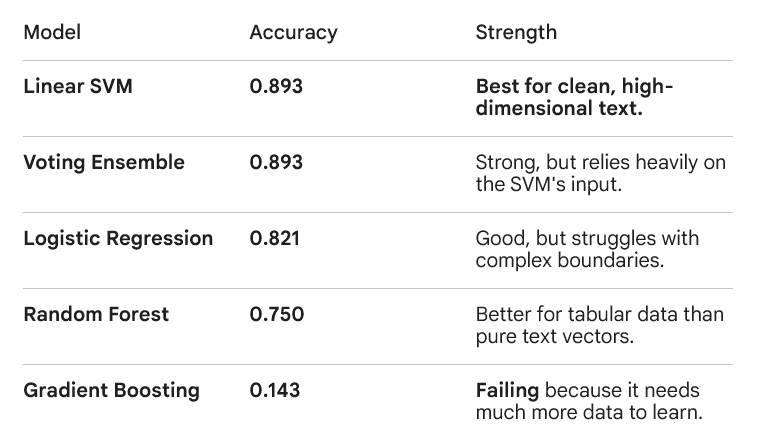

In [ ]:
# Implementing Linear SVM
X_train, X_test, y_train, y_test = train_test_split(
    training_sentences,
    training_labels,
    test_size=0.3,
    stratify=training_labels,
    random_state=42
)

# The vectorizer was already fitted on all training_sentences in a previous step.
# Here, we only transform the training and test subsets.
X_train_vec = vectorizer.transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LinearSVC(class_weight='balanced', C=1.0, random_state=42)
model.fit(X_train_vec, y_train)

LinearSVC(class_weight='balanced', random_state=42)

📈 Step 8: Evaluation

In [ ]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9166666666666666

Classification Report:
                 precision    recall  f1-score   support

ai_application       1.00      1.00      1.00         6
       goodbye       0.67      1.00      0.80         4
      greeting       1.00      0.60      0.75         5
 lemmatization       1.00      0.67      0.80         3
      nlp_core       1.00      1.00      1.00         6
      stemming       1.00      1.00      1.00         3
 tfidf_concept       0.86      1.00      0.92         6
  tokenization       1.00      1.00      1.00         3

      accuracy                           0.92        36
     macro avg       0.94      0.91      0.91        36
  weighted avg       0.94      0.92      0.91        36



In [ ]:
# 2. Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Calculate all metrics (using 'macro' average for multi-class)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
mcc = matthews_corrcoef(y_test, y_pred)

# For Specificity, FPR, FNR, NPV, and FDR in multi-class:
# We calculate them per class and then average them
def multiclass_metrics(y_true, y_pred):
    labels = np.unique(y_true)
    m_cm = confusion_matrix(y_true, y_pred, labels=labels)

    fp = m_cm.sum(axis=0) - np.diag(m_cm)
    fn = m_cm.sum(axis=1) - np.diag(m_cm)
    tp = np.diag(m_cm)
    tn = m_cm.sum() - (fp + fn + tp)

    # Avoid division by zero
    def safe_div(n, d): return np.divide(n, d, out=np.zeros_like(n, dtype=float), where=d!=0)

    spec = safe_div(tn, (tn + fp))
    fpr = safe_div(fp, (fp + tn))
    fnr = safe_div(fn, (fn + tp))
    npv = safe_div(tn, (tn + fn))
    fdr = safe_div(fp, (tp + fp))

    return spec.mean(), fpr.mean(), fnr.mean(), npv.mean(), fdr.mean()

specificity, fpr, fnr, npv, fdr = multiclass_metrics(y_test, y_pred)

# 4. Print results in your requested format
print("Confusion Matrix:\n", cm)
print("-" * 30)
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"FPR:         {fpr:.4f}")
print(f"FNR:         {fnr:.4f}")
print(f"NPV:         {npv:.4f}")
print(f"FDR:         {fdr:.4f}")
print(f"MCC:         {mcc:.4f}")

Confusion Matrix:
 [[6 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0]
 [0 2 3 0 0 0 0 0]
 [0 0 0 2 0 0 1 0]
 [0 0 0 0 6 0 0 0]
 [0 0 0 0 0 3 0 0]
 [0 0 0 0 0 0 6 0]
 [0 0 0 0 0 0 0 3]]
------------------------------
Accuracy:    0.9167
Precision:   0.9405
Recall:      0.9083
Specificity: 0.9880
F1 Score:    0.9091
FPR:         0.0120
FNR:         0.0917
NPV:         0.9887
FDR:         0.0595
MCC:         0.9076


🔁 Step 9: Cross Validation

In [ ]:
# The vectorizer was already fitted on all training_sentences previously.
# We only need to transform the data here.
X_all = vectorizer.transform(training_sentences)

scores = cross_val_score(model, X_all, training_labels, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.75       0.54166667 0.73913043 0.82608696 0.7826087 ]
Mean accuracy: 0.7278985507246377


📊 Step 10: Visualisation

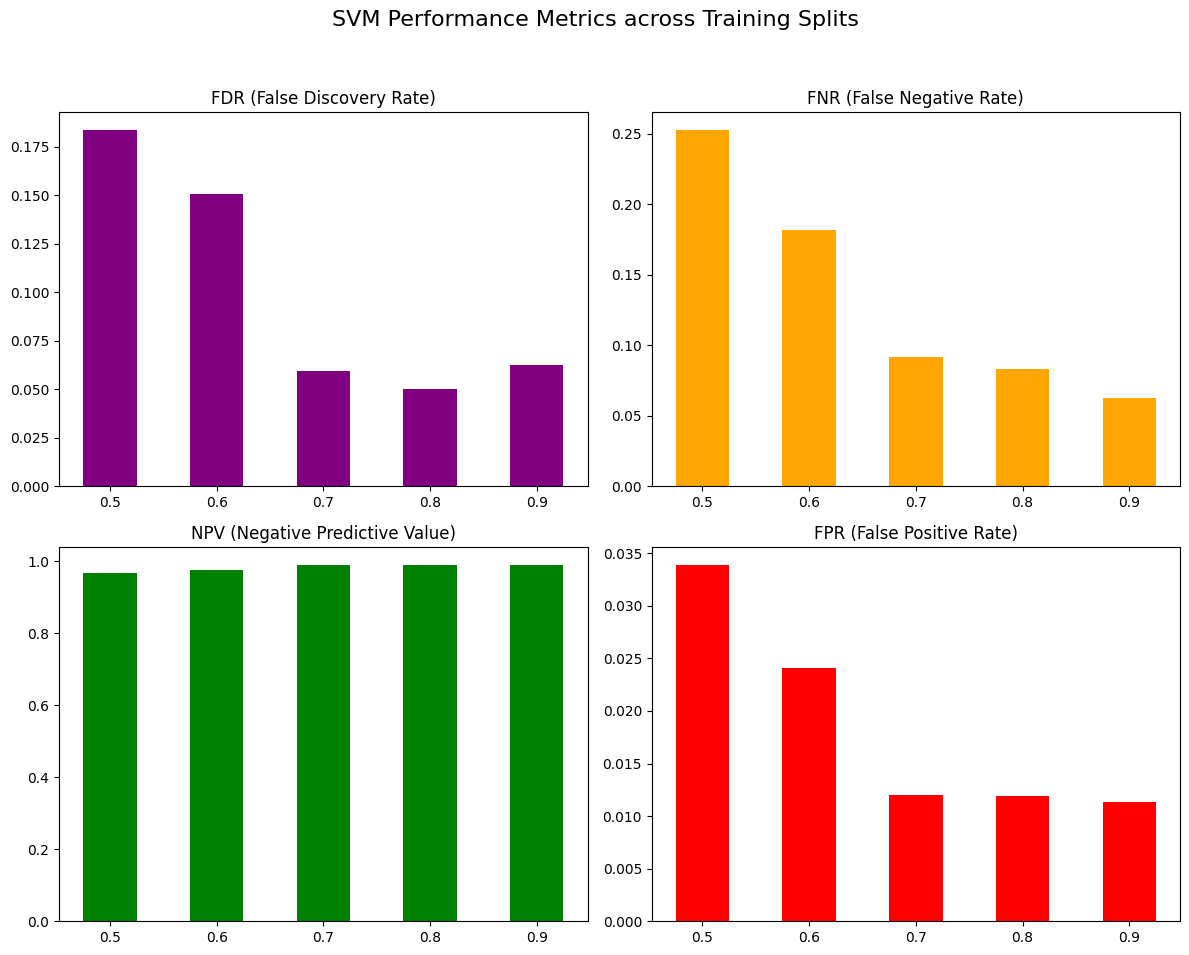

In [ ]:
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC

# 1. Setup variables for multiple splits
splits = [0.5, 0.6, 0.7, 0.8, 0.9]
fpr_list, fnr_list, npv_list, fdr_list = [], [], [], []

def get_metrics(y_true, y_pred):
    labels = np.unique(y_true)
    m_cm = confusion_matrix(y_true, y_pred, labels=labels)
    fp = m_cm.sum(axis=0) - np.diag(m_cm)
    fn = m_cm.sum(axis=1) - np.diag(m_cm)
    tp = np.diag(m_cm)
    tn = m_cm.sum() - (fp + fn + tp)
    def safe_div(n, d): return np.divide(n, d, out=np.zeros_like(n, dtype=float), where=d!=0)
    return (safe_div(fp, (fp + tn)).mean(), safe_div(fn, (fn + tp)).mean(),
            safe_div(tn, (tn + fn)).mean(), safe_div(fp, (tp + fp)).mean())

# 2. Run simulation across splits
for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        training_sentences, training_labels, test_size=(1-split), random_state=42, stratify=training_labels
    )

    # Use the globally fitted vectorizer for transformation
    X_train_vec = vectorizer.transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LinearSVC(class_weight='balanced', C=1.0, random_state=42)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    # Collect Metrics
    metrics = get_metrics(y_test, y_pred)
    fpr_list.append(metrics[0]); fnr_list.append(metrics[1])
    npv_list.append(metrics[2]); fdr_list.append(metrics[3])

# 3. Create the 2x2 Bar Chart Grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].bar(splits, fdr_list, width=0.05, color='purple')
axs[0, 0].set_title("FDR (False Discovery Rate)")

axs[0, 1].bar(splits, fnr_list, width=0.05, color='orange')
axs[0, 1].set_title("FNR (False Negative Rate)")

axs[1, 0].bar(splits, npv_list, width=0.05, color='green')
axs[1, 0].set_title("NPV (Negative Predictive Value)")

axs[1, 1].bar(splits, fpr_list, width=0.05, color='red')
axs[1, 1].set_title("FPR (False Positive Rate)")

plt.suptitle("SVM Performance Metrics across Training Splits", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

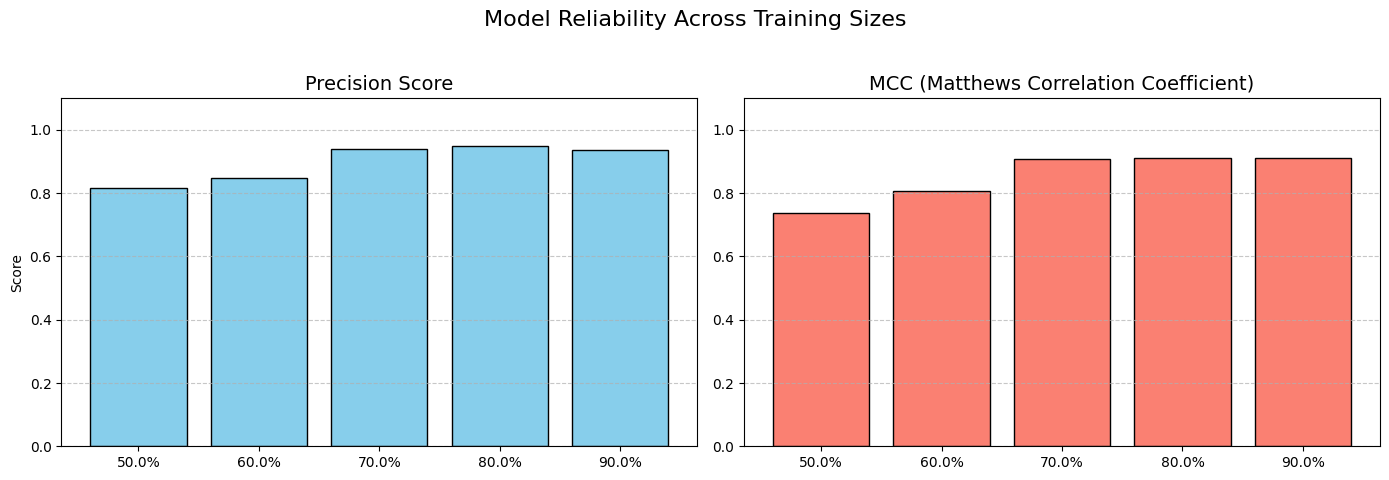

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, matthews_corrcoef

# 1. Setup variables
splits = [0.5, 0.6, 0.7, 0.8, 0.9]
precision_list = []
mcc_list = []

# 2. Run simulation across splits
for split in splits:
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        training_sentences, training_labels,
        test_size=(1-split),
        random_state=42,
        stratify=training_labels
    )

    # Use the globally fitted vectorizer for transformation
    X_train_vec = vectorizer.transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LinearSVC(class_weight='balanced', C=1.0, random_state=42)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    # Calculate Precision (Macro average for multiple tags) and MCC
    precision_list.append(precision_score(y_test, y_pred, average='macro'))
    mcc_list.append(matthews_corrcoef(y_test, y_pred))

# 3. Create Side-by-Side Visualization
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot Precision
axs[0].bar([str(s*100)+"%" for s in splits], precision_list, color='skyblue', edgecolor='black')
axs[0].set_title("Precision Score", fontsize=14)
axs[0].set_ylim(0, 1.1)
axs[0].set_ylabel("Score")
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot MCC
axs[1].bar([str(s*100)+"%" for s in splits], mcc_list, color='salmon', edgecolor='black')
axs[1].set_title("MCC (Matthews Correlation Coefficient)", fontsize=14)
axs[1].set_ylim(0, 1.1)
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Model Reliability Across Training Sizes", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

💬 Step 11: Chatbot (FINAL)

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
import random

# 1. Calibrate the SVM so it can give 'probabilities' (Confidence)
# We use the 'model' variable from your previous SVM training cell
calibrated_svc = CalibratedClassifierCV(model, cv='prefit')
calibrated_svc.fit(X_train_vec, y_train)

def chatbot():
    print("🤖 SVM-Powered Bot is Online! (type 'exit' to quit)")
    print("-" * 50)
    while True:
        user_input = input("You: ")
        if user_input.lower() == "exit":
            print("🤖 Goodbye!")
            break

        # Preprocess and Vectorize
        processed = preprocess(user_input)
        vector = vectorizer.transform([processed])

        # Get Probabilities
        probs = calibrated_svc.predict_proba(vector)[0]
        confidence = max(probs)
        tag = calibrated_svc.classes_[probs.argmax()]

        # 2. Confidence Check
        if confidence < 0.35:
            print(f"🤖 (Confidence: {confidence:.2f}) I'm not 100% sure. Are you asking about NLP basics or maybe a product review?")
        else:
            # Pick a random response from your intents.json mapping
            print(f"🤖 (Tag: {tag} | Conf: {confidence:.2f}) {random.choice(responses[tag])}")

# Launch the test
chatbot()

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


🤖 SVM-Powered Bot is Online! (type 'exit' to quit)
--------------------------------------------------
You: exit
🤖 Goodbye!


# Section 3 : Orchestration

In [ ]:
!pip install langgraph langchain

Defining States

In [ ]:
from typing import TypedDict

class State(TypedDict):
    input: str
    query_type: str
    response: str

Defining Nodes

In [ ]:
def router(state):
    raw_text = state["input"].lower()
    processed_text = preprocess(raw_text) # Use the existing preprocess function
    processed_words = processed_text.split() # Split into words for whole word matching

    chatbot_keywords = ["what", "define", "explain", "ai", "nlp", "hi", "bye", "hello", "hey", "morning", "greetings", "stemming", "tf-idf","tokenization", "lemmatization"]
    sentiment_keywords = ["product", "review", "good", "great", "excellent", "amazing", "nice", "super", "wonderful", "awesome", "best", "perfect", "smooth", "easy", "bad", "poor", "worst", "terrible", "slow", "fade", "waste", "problem", "issue", "not", "dont", "didnt", "drain", "drains", "weak", "cheap", "faulty", "broken", "price", "quality", "customer service", "experience"]

    # Check for whole word presence using set intersection for robustness
    processed_word_set = set(processed_words)
    is_chatbot_query = bool(processed_word_set.intersection(chatbot_keywords))
    is_sentiment_query = bool(processed_word_set.intersection(sentiment_keywords))

    if is_sentiment_query:
        return {"query_type": "sentiment"}
    elif is_chatbot_query:
        return {"query_type": "chatbot"}
    else:
        return {"query_type": "chatbot"}


In [ ]:
def chatbot_node(state):
  user_input = state['input']
  # Preprocess and Vectorize
  processed = preprocess(user_input)
  vector = vectorizer.transform([processed])
  # Get Probabilities
  probs = calibrated_svc.predict_proba(vector)[0]
  confidence = max(probs)
  tag = calibrated_svc.classes_[probs.argmax()]

  response_text = ""
  # Confidence Check
  if confidence < 0.35:
      response_text = f"🤖 (Confidence: {confidence:.2f}) I'm not 100% sure. Are you asking about NLP basics or maybe a product review?"
  else:
      # Pick a random response from your intents.json mapping
      response_text = f"🤖 (Tag: {tag} | Conf: {confidence:.2f}) {random.choice(responses[tag])}"
  # Print the response to mimic the original chatbot behavior
  print(response_text)
  return {'response': response_text} # Return the response to update the state

In [ ]:
def sentiment_node(state):
    user_input = state['input']
    result = full_sentiment_output(user_input) # Assuming full_sentiment_output exists globally
    return {'response': result}




In [ ]:
def route_decision(state):
    if state["query_type"] == "chatbot":
        return "chatbot_node"
    else:
        return "sentiment_node"


Connecting Nodes

In [ ]:
from langgraph.graph import StateGraph

builder = StateGraph(State)

builder.add_node("router", router)
builder.add_node("chatbot_node", chatbot_node)
builder.add_node("sentiment_node", sentiment_node)

builder.set_entry_point("router")

builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "chatbot_node": "chatbot_node",
        "sentiment_node": "sentiment_node"
    }
)

builder.set_finish_point("chatbot_node")
builder.set_finish_point("sentiment_node")

graph = builder.compile()

In [ ]:
# Example of running the pipeline
initial_state_chatbot = {'input': 'hi', 'query_type': '', 'response': ''}
result_chatbot = graph.invoke(initial_state_chatbot)
print("Chatbot Result:", result_chatbot)

# Example of running the pipeline for sentiment analysis
initial_state_sentiment = {'input': 'This product is good but the price is bad', 'query_type': '', 'response': ''}
result_sentiment = graph.invoke(initial_state_sentiment)
print("\nSentiment Result:", result_sentiment)


🤖 (Tag: greeting | Conf: 0.92) Hi there! Ready to talk about data science?
Chatbot Result: {'input': 'hi', 'query_type': 'chatbot', 'response': '🤖 (Tag: greeting | Conf: 0.92) Hi there! Ready to talk about data science?'}

Sentiment Result: {'input': 'This product is good but the price is bad', 'query_type': 'sentiment', 'response': 'Overall Sentiment: Negative\n\nAspect-Based Sentiment:\n- product: Positive'}


In [ ]:
test_cases = [
    "Hi how are you?",
    "what is NLP?",
    "what is ai?",
    "what is machine learning?",
    "what is deep learning?",
    "what is natural language processing?",
    "what is stemming?",
    "word splitting nlp",
    "How tf-idf works?",
    "Camera is great but battery is bad",
    "Camera quality is amazing but battery drains fast",
    "Sound is great but build quality is poor",
    "Display is excellent but performance is slow",
    "This product is amazing and works perfectly",
    "Excellent quality and great value for money",
    "Very bad product, stopped working in one week",
    "Worst experience, waste of money",
    "Good design but not durable",
    "Looks nice but performance is terrible",
    "Battery backup is good but charging is slow",
    "Product is okay, nothing special"
]

for text in test_cases:
    print("Input:", text)

    result = graph.invoke({
        "input": text,
        "query_type": "",
        "response": ""
    })

    print("Output:", result["response"])
    print("_"*50)

Input: Hi how are you?
🤖 (Tag: greeting | Conf: 0.58) Hey! How can I help you today?
Output: 🤖 (Tag: greeting | Conf: 0.58) Hey! How can I help you today?
__________________________________________________
Input: what is NLP?
🤖 (Tag: nlp_core | Conf: 0.91) NLP (Natural Language Processing) is a field of AI that gives computers the ability to understand, interpret, and generate human language.
Output: 🤖 (Tag: nlp_core | Conf: 0.91) NLP (Natural Language Processing) is a field of AI that gives computers the ability to understand, interpret, and generate human language.
__________________________________________________
Input: what is ai?
🤖 (Tag: ai_application | Conf: 0.86) AI is used in healthcare for diagnosis, finance for fraud detection, recommendation systems like Netflix, and self-driving cars.
Output: 🤖 (Tag: ai_application | Conf: 0.86) AI is used in healthcare for diagnosis, finance for fraud detection, recommendation systems like Netflix, and self-driving cars.
________________